In [1]:
# CELL 1: Setup & Imports
!pip install yfinance pandas-datareader statsmodels plotly seaborn kaleido==0.2.1 -q

import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import yfinance as yf
import pandas_datareader.data as web
import statsmodels.api as sm
from statsmodels.regression.rolling import RollingOLS
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
from datetime import datetime, timedelta

# Set plot style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("tab10")

In [2]:
# CELL 2: Data Acquisition & Preprocessing
class FactorDataLoader:
    """Handles the downloading and alignment of Fama-French 5 factors and equity returns."""

    def __init__(self, start_date, end_date):
        self.start = start_date
        self.end = end_date

    def get_fama_french_factors(self):
        """Fetches FF 5-Factor daily data."""
        print("Fetching Fama-French Factors")
        try:
            ff5 = web.DataReader('F-F_Research_Data_5_Factors_2x3_daily', 'famafrench', self.start, self.end)[0]

            # Convert pandas PeriodDtype to Timestamps
            ff5 = ff5.to_timestamp()

            # Force identical index formats
            ff5.index = pd.to_datetime(ff5.index).normalize()
            ff5.columns = ff5.columns.str.strip()
            ff5.rename(columns={'Mkt-RF': 'MKT'}, inplace=True)

            # Scale properly
            factors = ff5.dropna() / 100.0

            print(f"  -> FF Data loaded: {len(factors)} rows (From {factors.index.min().date()} to {factors.index.max().date()})")
            return factors

        except Exception as e:
            print(f"Error fetching FF data: {e}")
            return None

    def get_equity_returns(self, tickers):
        """Fetches daily adjusted close prices and calculates returns."""
        print(f"Fetching Equity Data for {tickers}")
        try:
            raw_data = yf.download(tickers, start=self.start, end=self.end, progress=False, auto_adjust=True)
            prices = raw_data['Close']

            if isinstance(prices, pd.Series):
                prices = prices.to_frame(tickers[0])

            # Strip timezones AND normalize to midnight (00:00:00)
            prices.index = pd.to_datetime(prices.index).tz_localize(None).normalize()

            returns = prices.pct_change().dropna()

            print(f"  -> Equity Data loaded: {len(returns)} rows (From {returns.index.min().date()} to {returns.index.max().date()})")
            return returns

        except Exception as e:
            print(f"Error fetching Equity data: {e}")
            return None

    def create_analysis_dataset(self, tickers):
        """Merges factors and returns into a single aligned dataframe."""
        factors = self.get_fama_french_factors()
        returns = self.get_equity_returns(tickers)

        if factors is None or returns is None:
            raise ValueError("Data fetching failed. Cannot proceed.")

        # Inner join to perfectly align dates
        data = returns.join(factors, how='inner')
        print(f"  -> Successfully joined data. Final shape: {data.shape}")
        return data

# Define a fixed five-year analysis window for reproducibility
end_date = datetime(2026, 6, 30)
start_date = end_date - timedelta(days=365 * 5)

loader = FactorDataLoader(start_date, end_date)
tickers = ['AAPL', 'JPM']
dataset = loader.create_analysis_dataset(tickers)

print("\nDataset Head:")
display(dataset.head())

Fetching Fama-French Factors
  -> FF Data loaded: 1254 rows (From 2021-07-01 to 2026-06-30)
Fetching Equity Data for ['AAPL', 'JPM']
  -> Equity Data loaded: 1252 rows (From 2021-07-02 to 2026-06-29)
  -> Successfully joined data. Final shape: (1252, 8)

Dataset Head:


,AAPL,JPM,MKT,SMB,HML,RMW,CMA,RF
Date,,,,,,,,
2021-07-02,0.019596,-0.000960,0.0056,-0.0153,-0.0070,0.0066,-0.0014,0.0
2021-07-06,0.014718,-0.016792,-0.0027,-0.0102,-0.0200,0.0055,-0.0075,0.0
2021-07-07,0.017955,0.001173,0.0010,-0.0084,0.0008,0.0170,0.0035,0.0
2021-07-08,-0.009200,-0.017254,-0.0086,-0.0001,-0.0079,-0.0022,-0.0003,0.0
2021-07-09,0.013055,0.031999,0.0126,0.0085,0.0157,-0.0017,0.0041,0.0


In [3]:
# CELL 3: Core Econometric Models (Static & Rolling OLS)
class FactorModeler:
    """Performs static and rolling OLS factor regressions."""

    def __init__(self, data, target_ticker, factors=['MKT', 'SMB', 'HML', 'RMW', 'CMA']):
        self.data = data.copy()
        self.target = target_ticker
        self.factors = factors

        # Calculate excess returns for the target asset
        self.data['Excess_Ret'] = self.data[self.target] - self.data['RF']

        self.X = sm.add_constant(self.data[self.factors])
        self.y = self.data['Excess_Ret']

    def static_regression(self):
        """Runs a standard OLS regression over the entire time period."""
        model = sm.OLS(self.y, self.X)
        results = model.fit()
        return results

    def rolling_regression(self, window=126):
        """Runs a rolling OLS regression to capture time-varying betas (126 days ~ 6 months)."""
        rolling_model = RollingOLS(self.y, self.X, window=window)
        rolling_results = rolling_model.fit()
        return rolling_results.params # Returns a dataframe of rolling betas

# Run models for AAPL
modeler_aapl = FactorModeler(dataset, 'AAPL')
static_res_aapl = modeler_aapl.static_regression()
rolling_betas_aapl = modeler_aapl.rolling_regression(window=126)

In [4]:
# CELL 4: Return Attribution Calculation
def calculate_attribution(data, rolling_betas, factors):
    """
    Decomposes excess return into factor contributions, estimated alpha, and residual return.
    Attribution = Beta(t-1) * Factor_Return(t)
    """
    attribution = pd.DataFrame(index=data.index)

    # Shift betas by 1 period to prevent look-ahead bias
    # (We use yesterday's beta to predict today's return)
    shifted_betas = rolling_betas.shift(1)

    for factor in factors:
        attribution[f'{factor}_Contrib'] = shifted_betas[factor] * data[factor]

    # Estimated alpha contribution from the rolling regression intercept
    attribution['Alpha_Contrib'] = shifted_betas['const']

    # Calculate Unexplained (Residual) Return
    attribution['Total_Factor_Contrib'] = attribution[[f'{f}_Contrib' for f in factors]].sum(axis=1) + attribution['Alpha_Contrib']
    attribution['Excess_Return'] = data['Excess_Ret']
    attribution['Residual'] = attribution['Excess_Return'] - attribution['Total_Factor_Contrib']

    return attribution.dropna()

factors_list = ['MKT', 'SMB', 'HML', 'RMW', 'CMA']

attrib_aapl = calculate_attribution(
    modeler_aapl.data,
    rolling_betas_aapl,
    factors_list
)

print("Attribution calculated successfully")

# Sum daily contributions for additive attribution
contribution_cols = [
    'MKT_Contrib',
    'SMB_Contrib',
    'HML_Contrib',
    'RMW_Contrib',
    'CMA_Contrib',
    'Alpha_Contrib',
    'Residual'
]

cumulative_contributions = attrib_aapl[contribution_cols].sum()

# Actual compounded cumulative excess return
cumulative_excess_return = (
    (1 + attrib_aapl['Excess_Return']).prod() - 1
)

# Create summary table
attribution_summary = pd.DataFrame({
    'Cumulative Contribution (pp)': cumulative_contributions * 100
})

# Display results
print(f"\nAAPL Cumulative Excess Return: {cumulative_excess_return:.2%}")
print("\n--- AAPL Return Attribution ---")

display(
    attribution_summary.round(2)
)


Attribution calculated successfully

AAPL Cumulative Excess Return: 35.17%

--- AAPL Return Attribution ---


,Cumulative Contribution (pp)
MKT_Contrib,50.95
SMB_Contrib,-0.83
HML_Contrib,-17.77
RMW_Contrib,-11.59
CMA_Contrib,36.37
Alpha_Contrib,5.97
Residual,-15.25


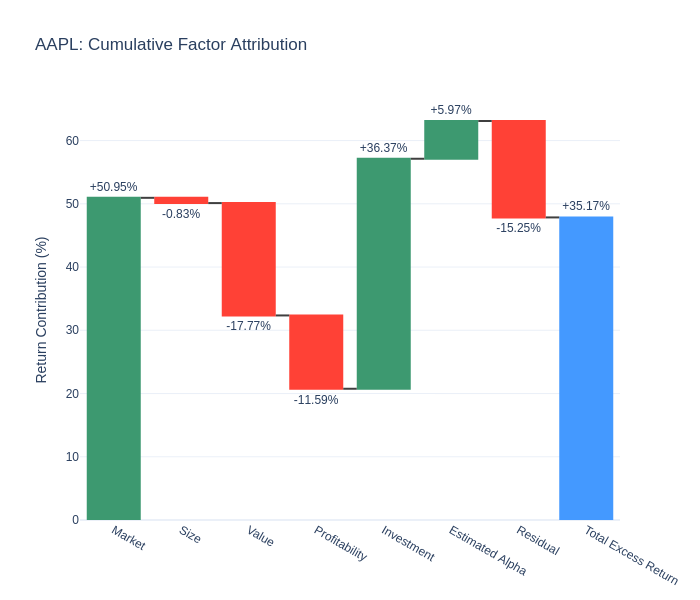

Note: Factor contributions are additive daily return contributions summed over the sample, while total excess return is compounded.


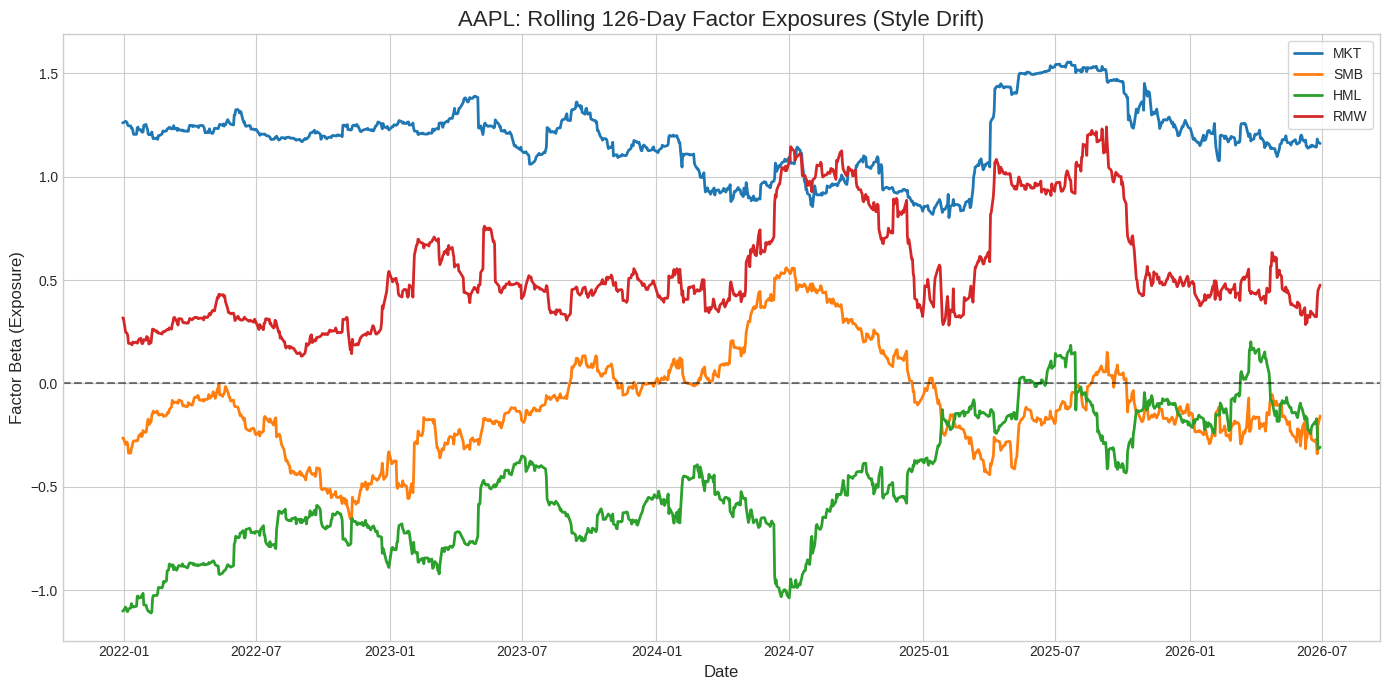

In [5]:
# CELL 5: Return Attribution & Factor Exposure Visualizations

def plot_waterfall_attribution(attrib_df, ticker):
    """
    Creates a cumulative return attribution waterfall
    based on summed daily factor contributions.
    """

    contribution_cols = [
        'MKT_Contrib',
        'SMB_Contrib',
        'HML_Contrib',
        'RMW_Contrib',
        'CMA_Contrib',
        'Alpha_Contrib',
        'Residual'
    ]

    total_contribs = attrib_df[contribution_cols].sum()

    # Convert to percentages
    values = total_contribs.values * 100

    labels = [
        'Market',
        'Size',
        'Value',
        'Profitability',
        'Investment',
        'Estimated Alpha',
        'Residual'
    ]

    # Actual cumulative excess return
    total_return = (
        (1 + attrib_df['Excess_Return']).prod() - 1
    ) * 100

    fig = go.Figure(
        go.Waterfall(
            name="Attribution",
            orientation="v",
            measure=["relative"] * len(values) + ["total"],
            x=labels + ["Total Excess Return"],
            textposition="outside",
            text=[f"{v:+.2f}%" for v in values]
                 + [f"{total_return:+.2f}%"],
            y=list(values) + [total_return],
            connector={
                "line": {
                    "color": "rgb(63, 63, 63)"
                }
            },
        )
    )

    fig.update_layout(
        title=f"{ticker}: Cumulative Factor Attribution",
        showlegend=False,
        template="plotly_white",
        height=600,
        yaxis_title="Return Contribution (%)"
    )

    fig.show(renderer="png")

def plot_rolling_betas(rolling_betas, ticker):
    plt.figure(figsize=(14, 7))

    # Plot the four most interpretable exposures for readability.
    # CMA remains included in the regression and attribution analysis.
    plot_factors = ['MKT', 'SMB', 'HML', 'RMW']

    for factor in plot_factors:
        plt.plot(rolling_betas.index, rolling_betas[factor], label=factor, linewidth=2)

    plt.axhline(0, color='black', linestyle='--', alpha=0.5)
    plt.title(f"{ticker}: Rolling 126-Day Factor Exposures (Style Drift)", fontsize=16)
    plt.ylabel("Factor Beta (Exposure)", fontsize=12)
    plt.xlabel("Date", fontsize=12)
    plt.legend(loc='best', frameon=True)
    plt.tight_layout()
    plt.show()

plot_waterfall_attribution(attrib_aapl, 'AAPL')
print(
    "Note: Factor contributions are additive daily return contributions "
    "summed over the sample, while total excess return is compounded."
)
plot_rolling_betas(rolling_betas_aapl, 'AAPL')


--- Average 126-Day Rolling Factor Exposures ---


,AAPL,JPM
MKT,1.183,1.075
SMB,-0.099,-0.255
HML,-0.496,0.933
RMW,0.547,-0.250
CMA,0.356,-0.084



JPM Cumulative Excess Return: 94.83%

--- JPM Return Attribution ---


,Cumulative Contribution (pp)
MKT_Contrib,42.53
SMB_Contrib,5.12
HML_Contrib,23.73
RMW_Contrib,-0.04
CMA_Contrib,-14.87
Alpha_Contrib,27.48
Residual,-3.43


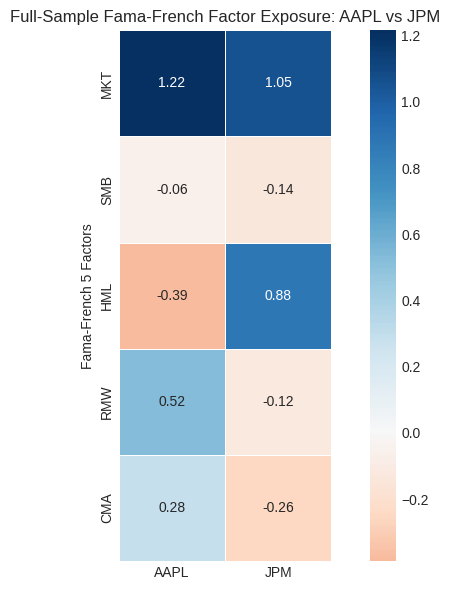

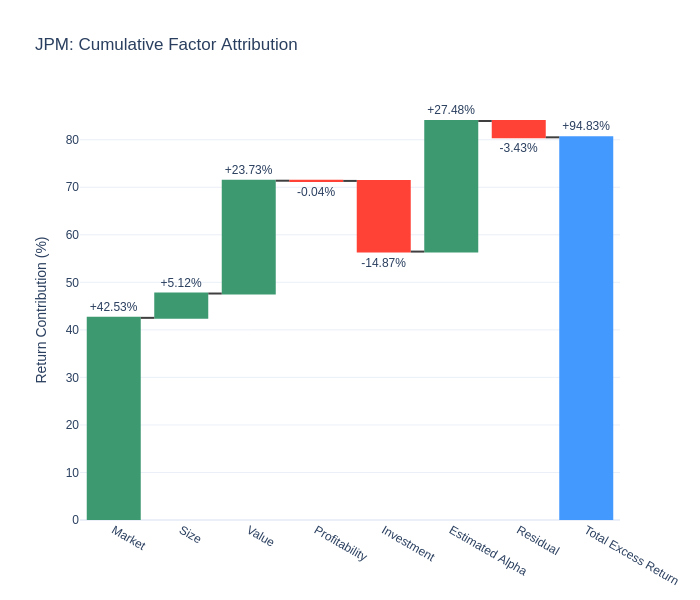


--- Key Findings ---
1. AAPL exhibited an average 126-day HML exposure of -0.496, while JPM exhibited +0.933, consistent with growth- and value-oriented characteristics, respectively.
2. AAPL's average market beta was 1.183, and the market factor contributed +50.95 percentage points to AAPL's cumulative return attribution.
3. JPM's estimated alpha contributed +27.47 percentage points to cumulative return attribution, compared with +5.97 percentage points for AAPL.

--- Final Takeaway ---
The analysis highlights a clear difference in the return drivers and factor profiles of AAPL and JPM. AAPL displayed growth-oriented characteristics through its negative HML exposure and its performance was driven primarily by systematic market exposure. In contrast, JPM displayed value-oriented characteristics through its positive HML exposure and a substantially larger estimated alpha contribution. This demonstrates how multi-factor attribution can distinguish broad market-driven performance from st

In [6]:
# CELL 6: Comparative Analysis (Growth vs. Value)
# Run the pipeline for JPM to compare exposures
modeler_jpm = FactorModeler(dataset, 'JPM')
static_res_jpm = modeler_jpm.static_regression()

# Run 126-day rolling regression for JPM
rolling_betas_jpm = modeler_jpm.rolling_regression(window=126)

# Average rolling factor exposures
rolling_exposure_comparison = pd.DataFrame({
    'AAPL': rolling_betas_aapl.mean(),
    'JPM': rolling_betas_jpm.mean()
})

print("\n--- Average 126-Day Rolling Factor Exposures ---")

display(
    rolling_exposure_comparison.loc[
        ['MKT', 'SMB', 'HML', 'RMW', 'CMA']
    ].round(3)
)

# Calculate JPM return attribution
attrib_jpm = calculate_attribution(
    modeler_jpm.data,
    rolling_betas_jpm,
    factors_list
)

# Calculate JPM cumulative excess return
cumulative_excess_return_jpm = (
    (1 + attrib_jpm['Excess_Return']).prod() - 1
)

# Calculate cumulative contributions
cumulative_contributions_jpm = (
    attrib_jpm[
        [
            'MKT_Contrib',
            'SMB_Contrib',
            'HML_Contrib',
            'RMW_Contrib',
            'CMA_Contrib',
            'Alpha_Contrib',
            'Residual'
        ]
    ].sum()
)

# Create JPM attribution table
attribution_summary_jpm = pd.DataFrame({
    'Cumulative Contribution (pp)':
        cumulative_contributions_jpm * 100
})

print(
    f"\nJPM Cumulative Excess Return: "
    f"{cumulative_excess_return_jpm:.2%}"
)

print("\n--- JPM Return Attribution ---")

display(
    attribution_summary_jpm.round(2)
)

# Extract parameters to a DataFrame for easy plotting
comparison_df = pd.DataFrame({
    'AAPL': static_res_aapl.params,
    'JPM': static_res_jpm.params
}).drop('const')

# Plot Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(comparison_df, annot=True, cmap='RdBu', center=0, fmt='.2f', cbar=True,
            linewidths=.5, square=True)
plt.title('Full-Sample Fama-French Factor Exposure: AAPL vs JPM')
plt.ylabel('Fama-French 5 Factors')
plt.tight_layout()
plt.show()

# JPM attribution waterfall
plot_waterfall_attribution(attrib_jpm, 'JPM')

print("\n--- Key Findings ---")

print(
    "1. AAPL exhibited an average 126-day HML exposure of -0.496, "
    "while JPM exhibited +0.933, consistent with growth- and "
    "value-oriented characteristics, respectively."
)

print(
    "2. AAPL's average market beta was 1.183, and the market factor "
    "contributed +50.95 percentage points to AAPL's cumulative "
    "return attribution."
)

print(
    "3. JPM's estimated alpha contributed +27.47 percentage points "
    "to cumulative return attribution, compared with +5.97 percentage "
    "points for AAPL."
)

print("\n--- Final Takeaway ---")

print(
    "The analysis highlights a clear difference in the return drivers "
    "and factor profiles of AAPL and JPM. AAPL displayed growth-oriented "
    "characteristics through its negative HML exposure and its performance "
    "was driven primarily by systematic market exposure. In contrast, "
    "JPM displayed value-oriented characteristics through its positive "
    "HML exposure and a substantially larger estimated alpha contribution. "
    "This demonstrates how multi-factor attribution can distinguish broad "
    "market-driven performance from stock-specific performance and reveal "
    "how equity factor exposures differ across companies."
)